# 01 · Data Understanding

**Phase 0 (background) + Phase 1 (load & understand) of the project plan.**

Goal of this notebook: load the raw NASA C-MAPSS data, understand exactly what a row represents physically, generate the RUL (Remaining Useful Life) target, and confirm the train-vs-test structure before doing any modeling.

We focus on **FD001** first (single operating condition, single fault mode — the simplest subset), and only look at FD002-FD004 for reference/comparison. This matches the plan's advice: *"Start with FD001. Don't combine subsets immediately."*

References:
- `docs/Damage Propagation Modeling.pdf` — Saxena, Goebel, Simon & Eklund (2008), the PHM08 challenge paper that generated this data via C-MAPSS (Commercial Modular Aero-Propulsion System Simulation).
- `docs/project_plan.pdf` — the 28-phase plan this notebook sequence follows.


## The physical system

Each engine unit is a simulated **turbofan engine** run by NASA's C-MAPSS simulator. A turbofan has 5 major stages that the paper's sensors track:

**Fan → LPC (Low-Pressure Compressor) → HPC (High-Pressure Compressor) → HPT (High-Pressure Turbine) → LPT (Low-Pressure Turbine)**

Every simulated engine starts with some (unknown, randomized) initial wear/manufacturing variation and degrades over time until a failure threshold is reached. In the **training** data, engines run all the way to failure. In the **test** data, engines are cut off at some point *before* failure — our job is to predict how many more cycles each one has left.

Every row = **one engine, one operational cycle**, with:
- `unit_number` — engine id
- `cycle` — the flight-cycle counter (like an odometer; resets to 1 for each engine)
- 3 **operational settings** (altitude, Mach number, throttle resolver angle) — define the flight condition, not engine health
- 21 **sensor measurements** (temperatures, pressures, speeds, flows, ratios) — carry the degradation signal


In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import data_loader as dl
from src import preprocessing as pp

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 4)
pd.set_option("display.max_columns", 40)

RAW_DIR = "../data/raw"
INTERIM_DIR = "../data/interim"
SUBSET = "FD001"


## The four subsets, at a glance

C-MAPSS ships as four subsets that differ in how many operating conditions and fault modes are simulated. We build the whole pipeline on FD001 first and revisit FD002/FD004 later (they need the operating-condition clustering step FD001 doesn't).


In [2]:
subset_overview = pd.DataFrame({name: vars(info) for name, info in dl.SUBSET_INFO.items()}).T
subset_overview


,train_trajectories,test_trajectories,conditions,fault_modes,description
FD001,100,100,1,1,"One operating condition (sea level), one fault..."
FD002,260,259,6,1,"Six operating conditions, one fault mode (HPC ..."
FD003,100,100,1,2,"One operating condition (sea level), two fault..."
FD004,248,249,6,2,"Six operating conditions, two fault modes (HPC..."


## Step 1.1 — Load FD001 and inspect shape/structure


In [3]:
train_raw = dl.load_train(SUBSET, data_dir=RAW_DIR)
test_raw = dl.load_test(SUBSET, data_dir=RAW_DIR)
rul_raw = dl.load_rul(SUBSET, data_dir=RAW_DIR)

print("train_raw:", train_raw.shape)
print("test_raw :", test_raw.shape)
print("rul_raw  :", rul_raw.shape)
train_raw.head()


train_raw: (20631, 26)
test_raw : (13096, 26)
rul_raw  : (100,)


,unit_number,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [4]:
train_raw.describe().T


,count,mean,std,min,25%,50%,75%,max
unit_number,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
cycle,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
op_setting_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
op_setting_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
op_setting_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
sensor_1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
sensor_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
sensor_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor_5,20631.0,14.620000,5.329200e-15,14.6200,14.6200,14.6200,14.6200,14.6200


## Physical meaning of every column

The 3 operational settings and 21 sensors are anonymized as `op_setting_1..3` / `sensor_1..21` in the raw files. `src/data_loader.py` carries the PHM08-paper mapping (Table 1 & 2) to real instrumentation symbols — useful now for orientation, and later for SHAP interpretation in `07_explainability.ipynb`.


In [5]:
op_setting_table = pd.DataFrame(dl.OP_SETTING_INFO).T
op_setting_table


,symbol,description,units
op_setting_1,Altitude,Flight altitude,ft
op_setting_2,Mach,Mach number,-
op_setting_3,TRA,Throttle Resolver Angle,deg


In [6]:
sensor_table = pd.DataFrame(dl.SENSOR_INFO).T
sensor_table


,symbol,description,units
sensor_1,T2,Total temperature at fan inlet,R
sensor_2,T24,Total temperature at LPC outlet,R
sensor_3,T30,Total temperature at HPC outlet,R
sensor_4,T50,Total temperature at LPT outlet,R
sensor_5,P2,Pressure at fan inlet,psia
sensor_6,P15,Total pressure in bypass duct,psia
sensor_7,P30,Total pressure at HPC outlet,psia
sensor_8,Nf,Physical fan speed,rpm
sensor_9,Nc,Physical core speed,rpm
sensor_10,epr,Engine pressure ratio (P50/P2),-


## Step 1.2 — One engine's life, up close

Before looking at the whole dataset, let's see what a single engine's trajectory looks like: how many cycles it ran, and how a couple of sensors move from a healthy start to end-of-life.


In [7]:
engine_1 = train_raw[train_raw["unit_number"] == 1]
print(f"Engine 1 ran for {engine_1['cycle'].max()} cycles before the training file ends (= failure).")
engine_1[["unit_number", "cycle", "sensor_2", "sensor_3", "sensor_4", "sensor_11"]].iloc[[0, -1]]


Engine 1 ran for 192 cycles before the training file ends (= failure).


,unit_number,cycle,sensor_2,sensor_3,sensor_4,sensor_11
0,1,1,641.82,1589.70,1400.6,47.47
191,1,192,643.54,1601.41,1427.2,48.25


count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


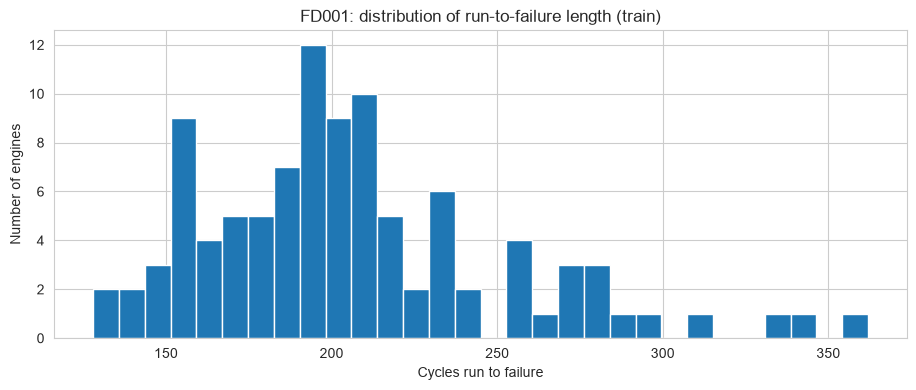

In [8]:
cycles_per_engine = train_raw.groupby("unit_number")["cycle"].max()
print(cycles_per_engine.describe())
cycles_per_engine.hist(bins=30)
plt.xlabel("Cycles run to failure")
plt.ylabel("Number of engines")
plt.title(f"{SUBSET}: distribution of run-to-failure length (train)")
plt.show()


## Step 1.3 — Generate the RUL target (training data)

For **training** engines we know the exact failure cycle (the last row for each engine *is* the failure), so:

`RUL_i,t = (last cycle observed for engine i) - t`

This is implemented in `src/preprocessing.add_rul`, grouped by `unit_number` so no engine's countdown leaks into another's.


In [9]:
train_with_rul = pp.add_rul(train_raw)
train_with_rul[["unit_number", "cycle", "RUL"]].head(8)


,unit_number,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187
5,1,6,186
6,1,7,185
7,1,8,184


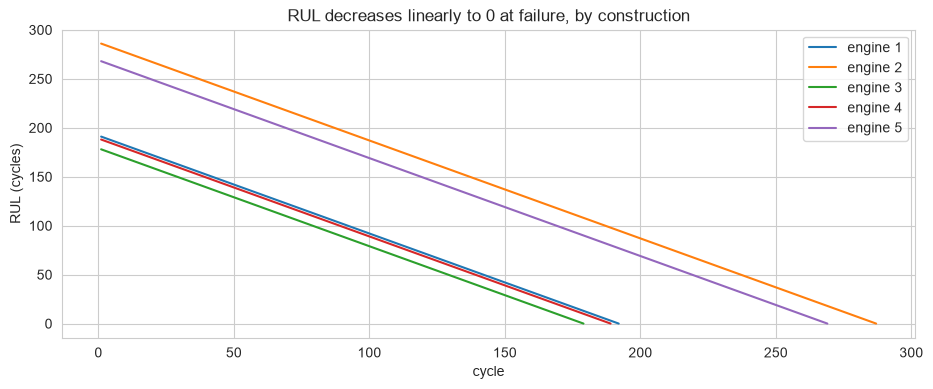

In [10]:
fig, ax = plt.subplots()
for engine_id in [1, 2, 3, 4, 5]:
    g = train_with_rul[train_with_rul["unit_number"] == engine_id]
    ax.plot(g["cycle"], g["RUL"], label=f"engine {engine_id}")
ax.set_xlabel("cycle")
ax.set_ylabel("RUL (cycles)")
ax.set_title("RUL decreases linearly to 0 at failure, by construction")
ax.legend()
plt.show()


## Step 1.4 — The test set is different: trajectories are truncated

Test engines are **cut off before failure** at some arbitrary cycle. `RUL_FD001.txt` gives the true remaining life *after* the last observed test cycle for each engine — that's the ground truth we predict against and never train on.

`src/preprocessing.add_rul_test` combines the two: for any cycle `t` in a test engine's history, `RUL_t = rul_at_end + (last_observed_cycle - t)`.


In [11]:
test_with_rul = pp.add_rul_test(test_raw, rul_raw)
test_with_rul[["unit_number", "cycle", "RUL"]].tail(8)


,unit_number,cycle,RUL
13088,100,191,27
13089,100,192,26
13090,100,193,25
13091,100,194,24
13092,100,195,23
13093,100,196,22
13094,100,197,21
13095,100,198,20


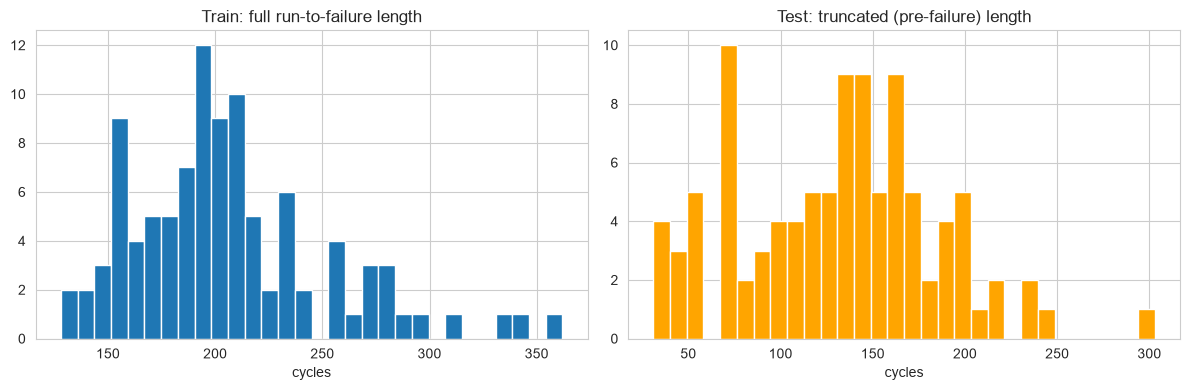

Test RUL-at-truncation summary (ground truth, RUL_FD001.txt):
count    100.00000
mean      75.52000
std       41.76497
min        7.00000
25%       32.75000
50%       86.00000
75%      112.25000
max      145.00000
Name: RUL, dtype: float64


In [12]:
train_lengths = train_with_rul.groupby("unit_number")["cycle"].max()
test_lengths = test_with_rul.groupby("unit_number")["cycle"].max()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_lengths.hist(bins=30, ax=axes[0])
axes[0].set_title("Train: full run-to-failure length")
axes[0].set_xlabel("cycles")

test_lengths.hist(bins=30, ax=axes[1], color="orange")
axes[1].set_title("Test: truncated (pre-failure) length")
axes[1].set_xlabel("cycles")
plt.tight_layout()
plt.show()

print("Test RUL-at-truncation summary (ground truth, RUL_FD001.txt):")
print(rul_raw.describe())


**Takeaway:** test trajectories are shorter than train trajectories on average (they were cut off early), and the ground-truth RUL at cutoff ranges widely — this is exactly why the task is hard: at inference time we only see a partial history and must estimate how much is left.


## Save interim outputs

Persisting `train_with_rul` / `test_with_rul` (+ the raw RUL series) to `data/interim/` so later notebooks don't have to repeat this loading step.


In [13]:
import os
os.makedirs(INTERIM_DIR, exist_ok=True)

train_with_rul.to_parquet(f"{INTERIM_DIR}/train_{SUBSET}_with_rul.parquet")
test_with_rul.to_parquet(f"{INTERIM_DIR}/test_{SUBSET}_with_rul.parquet")
rul_raw.to_frame(name="RUL").to_parquet(f"{INTERIM_DIR}/rul_{SUBSET}.parquet")

print("Saved to", INTERIM_DIR)


Saved to ../data/interim


## Summary

- Loaded FD001 train/test/RUL files via `src/data_loader.py`; confirmed shapes and column layout (26 raw columns: 2 id + 3 op-settings + 21 sensors).
- Mapped anonymized sensor/op-setting columns to their physical meaning from the PHM08 paper.
- Generated the `RUL` target for train (exact, run-to-failure) and test (via the supplied `RUL_FD001.txt` ground truth at truncation).
- Confirmed the key train/test asymmetry: train sees full degradation to failure, test is truncated early — the crux of the prediction problem.
- Saved interim train/test-with-RUL tables for reuse.

**Next:** `02_eda.ipynb` — sensor variance, distributions, degradation curves, smoothing, and correlation with RUL.
